# Notebook 03 - Textual Visualization

In this notebook we visualize our data regarding the stories textual informations. 

# 0. Setup

In [18]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis
from scipy import stats

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
import seaborn as sns 
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
from pathlib import Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system

def find_project_root(start=Path.cwd(), marker='data'): # defines a function to find the project root directory by looking for a specific marker (default is 'data')
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

from tools import text_tools # tools for text processing
from tools import dataframe_tools as dftools # tools for dataframe processing

In [19]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['dreams_in_the_witch.txt', 'ex_oblivione.txt', 'poetry_of_gods.txt', 'doorstep.txt', 'colour_out_of_space.txt', 'iranon.txt', 'street.txt', 'arthur_jermyn.txt', 'crawling_chaos.txt', 'ulthar.txt', 'azathoth.txt', 'shadow_out_of_time.txt', 'haunter.txt', 'martins_beach.txt', 'tree.txt', 'whisperer.txt', 'moon_bog.txt', 'unnamable.txt', 'beast.txt', 'alchemist.txt', 'terrible_old_man.txt', 'nameless.txt', 'reanimator.txt', 'celephais.txt', 'gates_of_silver_key.txt', 'medusas_coil.txt', 'dagon.txt', 'picture_house.txt', 'memory.txt', 'white_ship.txt', 'erich_zann.txt', 'tomb.txt', 'temple.txt', 'he.txt', 'pickman.txt', 'silver_key.txt', 'clergyman.txt', 'old_folk.txt', 'from_beyond.txt', 'descendent.txt', 'nyarlathotep.txt', 'vault.txt', 'hypnos.txt', 'polaris.txt', 'book.txt', 'shunned_house.txt', 'pharoahs.txt', 'randolph_carter.txt', 'innsmouth.txt', 'charles_dexter_ward.txt', 'dunwich.txt', 'festival.txt', 'other_gods.txt', 'redhook.txt', 'hound.txt', 'outsider.txt', 'mountains_of_ma

# 1. Text Metadata Visualization

In [20]:
biblio.df_texts.head()  # displays the first few rows of the DataFrame containing the text metadata

,text,file,sentence_count,word_count,vocabulary,character_count
0,dreams_in_the_witch,dreams_in_the_witch.txt,546,14626,4148,86779
1,ex_oblivione,ex_oblivione.txt,21,701,348,3814
2,poetry_of_gods,poetry_of_gods.txt,56,1866,862,10560
3,doorstep,doorstep.txt,422,10446,3297,60265
4,colour_out_of_space,colour_out_of_space.txt,500,12134,3475,68090


Text(0.5, 1.0, 'Word count distribution')

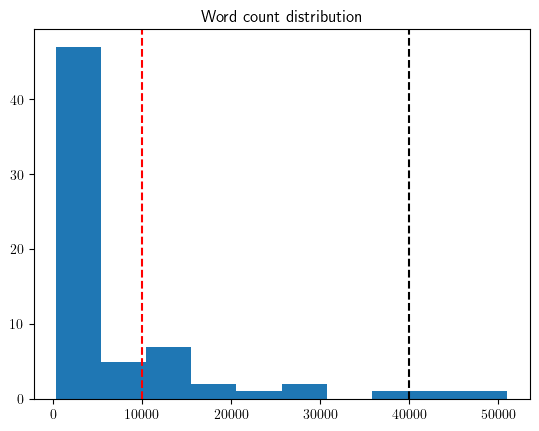

In [21]:
# word count histogram
plt.hist( biblio.df_texts['word_count'])  # creates a histogram of the word counts of the texts
plt.axvline( x = 1e4, color='red', linestyle='--', label='Novella' )
plt.axvline( x = 4e4, color='black', linestyle='--', label='Novel' )
plt.title('Word count distribution')

Text(0.5, 1.0, 'Sentence count distribution')

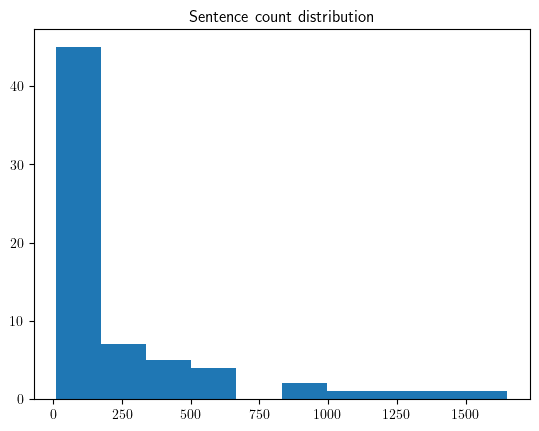

In [22]:
# sentence count histogram
plt.hist( biblio.df_texts['sentence_count'])  # creates a histogram of the sentence counts of the texts
plt.title('Sentence count distribution')

Text(0.5, 1.0, 'Vocabulary size distribution')

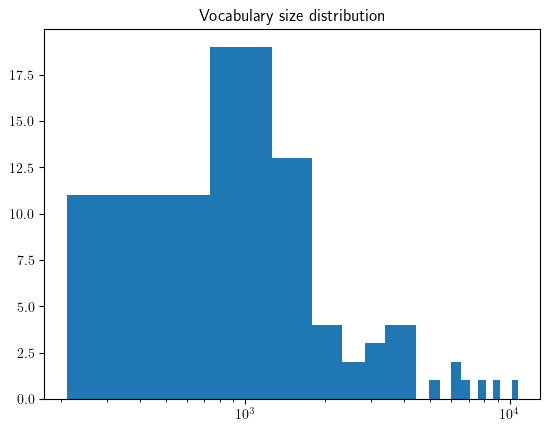

In [23]:
# vocabulary histogram
plt.hist( biblio.df_texts['vocabulary'], bins = 20)  # creates a histogram of the vocabulary sizes of the texts
plt.xscale('log')
plt.title('Vocabulary size distribution')

Text(0.5, 1.0, 'Character count distribution')

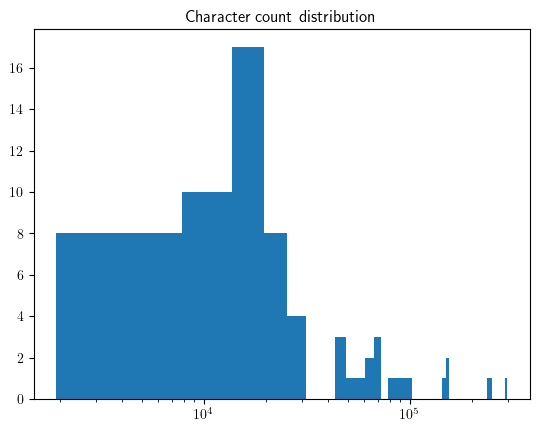

In [24]:
# character count histogram
plt.hist( biblio.df_texts['character_count'], bins = 50)  # creates a histogram of the character counts of the texts
plt.xscale('log') 
plt.title('Character count distribution')

Text(0.5, 1.0, 'Vocabulary to word count ratio distribution')

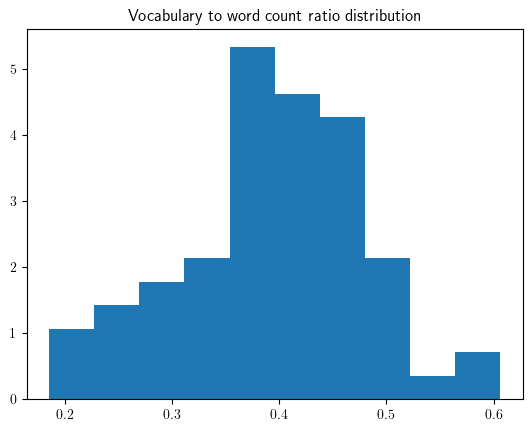

In [25]:
# vocabulary to word count ratio histogram

# vocabulary to word count
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

plt.hist( vocab_to_word, density=True )  # creates a histogram of the vocabulary sizes of the texts
plt.title('Vocabulary to word count ratio distribution')

Text(0.5, 1.0, 'Vocabulary to sentence count ratio distribution')

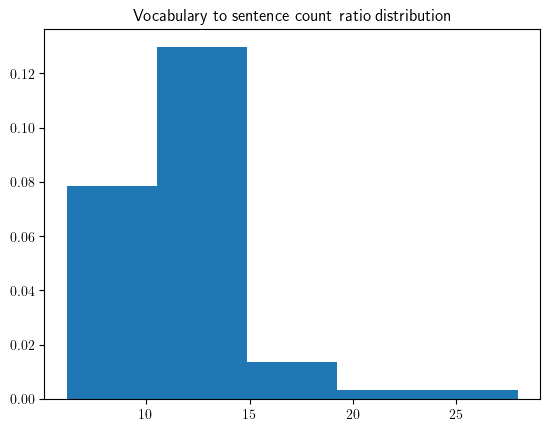

In [26]:
# vocabulary to sentence count 

vocabulary_to_sentence = biblio.df_texts['vocabulary']/biblio.df_texts['sentence_count']

plt.hist(vocabulary_to_sentence, density=True, bins= 5)
plt.title('Vocabulary to sentence count ratio distribution') 